In [1]:
import numpy as np

In [23]:
class LogisticRegressionGD(object):
    
    def __init__(self, eta = 0.5, n_iter = 100, random_state = 1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc = 0.0, scale = 0.01, size = 1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)

            eps = 1e-15
            output = self.activation(net_input)
            output = np.clip(output, eps, 1 - eps)
            
            error = (y - output)

            self.w_[1:] += self.eta * X.T.dot(error)
            self.w_[0] += self.eta * error.sum()
            

            cost = (-y.dot( np.log(output)) - (1 - y).dot(np.log(1 - output)))

            self.cost_.append(cost)
        return self
    
    def net_input(self, X):
        return np.dot(X , self.w_[1:]) + self.w_[0]
        
    def activation(self, z):
        return 1. / (1. + np.exp(- np.clip(z, -250, 250)))
        
    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

In [24]:
from sklearn import datasets

iris = datasets.load_iris()

X = iris.data[:, [2 , 3]]
y = iris.target

print("Class Labels: ", np.unique(y))

Class Labels:  [0 1 2]


In [25]:
# Shuffling manually by stratifying y 

np.random.seed(42)

train_ratio = 0.8

X_train = []
X_test = []
y_train = []
y_test = []

for cls in np.unique(y):
    cls_idx = np.where(y == cls)[0]

    np.random.shuffle(cls_idx)

    split = (int) (train_ratio * len(cls_idx))
    train_idx = cls_idx[:split]
    test_idx = cls_idx[split:]
    
    X_train.append(X[train_idx])
    y_train.append(y[train_idx])
    X_test.append(X[test_idx])
    y_test.append(y[test_idx])
    
X_train = np.vstack(X_train)
y_train = np.concatenate(y_train)

In [26]:
# Scaling

class StandardScaler:

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

scaler = StandardScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


In [27]:
# Training

lrgd = LogisticRegressionGD(eta = 0.05, n_iter = 1000, random_state = 1)

lrgd.fit(X_train, y_train)

In [29]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
def plot_decision_regions(X, y, classifier, test_idx=None, 
                          resolution=0.02):
    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), 
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], 
                    alpha=0.8, c=colors[idx], 
                    marker=markers[idx], label=cl, 
                    edgecolor='black')
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1], 
                    c='', edgecolor='black', alpha=1.0, 
                    linewidth=1, marker='o', 
                    s=100, label='test set')

C:\Users\sayed mohamed saqib\AppData\Local\Temp\ipykernel_26456\3018912471.py:20: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],


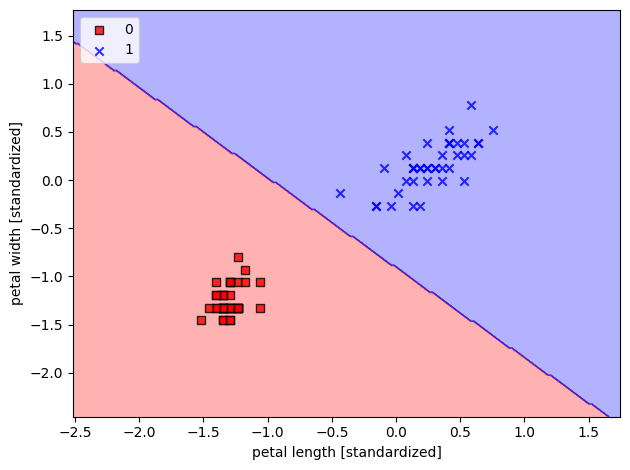

In [33]:
X_train_01_subset = X_train[(y_train == 0) | (y_train == 1)]
y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]

plot_decision_regions(X = X_train_01_subset, y = y_train_01_subset, classifier=lrgd)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()